# Tarea 1

## En esta tarea tenemos el objetivo de construir un retrato demográfico y migratorio de las  comunas que se nos asignaron utilizando los microdatos del Censo 2024.
Nota: Este trabajo se realizó con el apoyo de IA. Específicamente Gemini

### Parte 0: Cargar los datos y preparalos para su posterior uso

In [49]:
# Comenzamos cargando todas las librerias que vamos a utilizar en toda la tarea 
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [13]:
# Acá procederemos a cargar las distintas rutas 
ruta_viv = "C:/Users/Mateo/Downloads/viviendas_censo2024.parquet"
ruta_hog = "C:/Users/Mateo/Downloads/hogares_censo2024.parquet"
ruta_per = "C:/Users/Mateo/Downloads/personas_censo2024.parquet"

# Acá leemos las columnas que utilizaremos
cols_reales_viv = pq.ParquetFile(ruta_viv).schema.names
cols_reales_hog = pq.ParquetFile(ruta_hog).schema.names
cols_reales_per = pq.ParquetFile(ruta_per).schema.names

# y acá colocamos el nombre de las columnas en cuestion
cols_ideales_viv = [
    "id_vivienda", "region", "comuna", "codigo_comuna", "nombre_comuna", 
    "materialidad", "p4a_mat_paredes", "p4b_mat_techo", "p4c_mat_piso"
]
cols_ideales_hog = [
    "id_vivienda", "id_hogar", "hacinamiento", "indice_hacinamiento", 
    "tenencia", "p12_tenencia", "p1_tenencia"
]
cols_ideales_per = [
    "id_vivienda", "id_hogar", "id_persona", "sexo", "edad", "p8_sexo", "p9_edad",
    "p27_nacionalidad_esp", "p25_lug_nacimiento_rec", "p24_lug_resid5", 
    "p25_lug_nacimiento", "p26_llegada_periodo", "escolaridad", "cine11", 
    "sit_fuerza_trabajo", "cod_ciuo", "cod_caenes", "p45_medio_transporte"
]

# Nos quedamos SOLO con las columnas que sí existen en tus archivos
cols_def_viv = [c for c in cols_ideales_viv if c in cols_reales_viv]
cols_def_hog = [c for c in cols_ideales_hog if c in cols_reales_hog]
cols_def_per = [c for c in cols_ideales_per if c in cols_reales_per]

print("Cargando las siguientes columnas:")
print("- Vivienda:", cols_def_viv)
print("- Hogar:", cols_def_hog)
print("- Persona:", cols_def_per)

# Ahora Cargamos los archivos
df_viv = pd.read_parquet(ruta_viv, columns=cols_def_viv)
df_ho = pd.read_parquet(ruta_hog, columns=cols_def_hog)
df_pe = pd.read_parquet(ruta_per, columns=cols_def_per)

print("\n¡Carga exitosa!")
print(f"Dimensiones de vivienda: {df_viv.shape}")
print(f"Dimensiones de hogar: {df_ho.shape}")
print(f"Dimensiones de persona: {df_pe.shape}")



Cargando las siguientes columnas:
- Vivienda: ['id_vivienda', 'region', 'comuna', 'p4a_mat_paredes', 'p4b_mat_techo', 'p4c_mat_piso']
- Hogar: ['id_vivienda', 'id_hogar']
- Persona: ['id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad', 'p27_nacionalidad_esp', 'p25_lug_nacimiento_rec', 'p24_lug_resid5', 'p25_lug_nacimiento', 'p26_llegada_periodo', 'escolaridad', 'cine11', 'sit_fuerza_trabajo', 'cod_ciuo', 'cod_caenes', 'p45_medio_transporte']

¡Carga exitosa!
Dimensiones de vivienda: (7664466, 6)
Dimensiones de hogar: (6622597, 2)
Dimensiones de persona: (18480432, 16)


### Para ver que las bases de datos están correctas, procederemos a visualizar cada una

In [14]:
df_viv.head()

,id_vivienda,region,comuna,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso
0,1,5,5802,5.0,1.0,2.0
1,2,4,4303,2.0,3.0,3.0
2,3,11,11202,2.0,3.0,1.0
3,4,1,1101,1.0,2.0,1.0
4,5,8,8301,2.0,3.0,1.0


In [15]:
df_ho.head()

,id_vivienda,id_hogar
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [16]:
df_pe.head()

,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad_esp,p25_lug_nacimiento_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,escolaridad,cine11,sit_fuerza_trabajo,cod_ciuo,cod_caenes,p45_medio_transporte
0,1,1,1,2,80,152,1,3,2,NaN,17,9,3.0,NaN,None,NaN
1,1,1,2,1,52,152,1,2,2,NaN,14,6,1.0,7.0,F,2.0
2,1,1,3,2,45,152,1,2,2,NaN,12,6,1.0,2.0,P,3.0
3,1,1,4,2,8,152,1,2,1,NaN,2,3,NaN,NaN,None,NaN
4,2,1,1,1,69,152,1,3,2,NaN,12,6,3.0,NaN,None,NaN


In [17]:
# Para esta parte, definiermos los códigos de las comunas que nos tocó, las cuales son San Bernardo y Calera de Tango
MIS_COMUNAS = [13401, 13403] 

# Identificamos el nombre real de la columna de comuna en la tabla df_viv
col_comuna = "comuna" if "comuna" in df_viv.columns else "codigo_comuna"

# Filtramos la tabla de viviendas
viv = df_viv[df_viv[col_comuna].isin(MIS_COMUNAS)]

# Ahora usamos las viviendas filtradas para filtrar hogares y personas
hog = df_ho[df_ho["id_vivienda"].isin(viv["id_vivienda"])]
per = df_pe[df_pe["id_vivienda"].isin(viv["id_vivienda"])]

print("--- Filas después de filtrar ---")
print(f"Viviendas: {len(viv)}")
print(f"Hogares: {len(hog)}")
print(f"Personas: {len(per)}")

--- Filas después de filtrar ---
Viviendas: 111084
Hogares: 106912
Personas: 331862


In [18]:
# Unimos persona con hogar usando id_vivienda e id_hogar
# Luego unimos el resultado con vivienda usando id_vivienda
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
        .merge(viv, on="id_vivienda", how="left")

#Ahora verificamos que el número de filas luego del merge sea igual a la de las personas
assert len(df) == len(per), "¡Discrepancia en el conteo de filas tras la unión!"

# Hacemos el reporte
print("\n--- Resultado Final de la Unión ---")
print("Forma del DataFrame unido:", df.shape)
print("\nInformación del DataFrame:")
df.info()


--- Resultado Final de la Unión ---
Forma del DataFrame unido: (331862, 21)

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331862 entries, 0 to 331861
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             331862 non-null  int32  
 1   id_hogar                331862 non-null  int32  
 2   id_persona              331862 non-null  int32  
 3   sexo                    331862 non-null  int32  
 4   edad                    331862 non-null  int32  
 5   p27_nacionalidad_esp    331862 non-null  int32  
 6   p25_lug_nacimiento_rec  331862 non-null  int32  
 7   p24_lug_resid5          331862 non-null  int32  
 8   p25_lug_nacimiento      331862 non-null  int32  
 9   p26_llegada_periodo     20442 non-null   float64
 10  escolaridad             331862 non-null  int32  
 11  cine11                  331862 non-null  int32  
 12  sit_fuerza_trabajo     

In [23]:
#Comprobamos si el merge fué exitoso haciendo una pequeña visualización de la nueva bbdd
df.head()

,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad_esp,p25_lug_nacimiento_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,...,cod_ciuo,cod_caenes,p45_medio_transporte,region,comuna,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso,age_group,sexo_str
0,37,1,1,2,28,152,1,2,2,NaN,...,4.0,O,1.0,13,13401,2.0,4.0,1.0,25-29,Mujer
1,67,1,1,2,38,152,1,3,1,NaN,...,2.0,Q,4.0,13,13401,1.0,2.0,1.0,35-39,Mujer
2,208,1,1,2,35,152,1,3,2,NaN,...,2.0,R,1.0,13,13401,2.0,1.0,1.0,35-39,Mujer
3,208,1,2,1,37,152,1,3,2,NaN,...,6.0,N,1.0,13,13401,2.0,1.0,1.0,35-39,Hombre
4,208,1,3,1,1,152,1,1,2,NaN,...,NaN,None,NaN,13,13401,2.0,1.0,1.0,0-4,Hombre


## Parte 1
### Parte 1.1

In [20]:
#Antes de comenzar, verificaremos si es que la base de datos contiene algun valor -99.
#De llegar a contener al menos 1, se debe limpiar la base de de datos eliminandola.
edades_faltantes = (df["edad"] == -99).sum()
print(f"Personas con edad faltante (-99): {edades_faltantes}")

Personas con edad faltante (-99): 0


C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\393624837.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f"{abs(int(tick)):,}" for tick in ticks])
C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\393624837.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([f"{abs(int(tick)):,}" for tick in ticks])


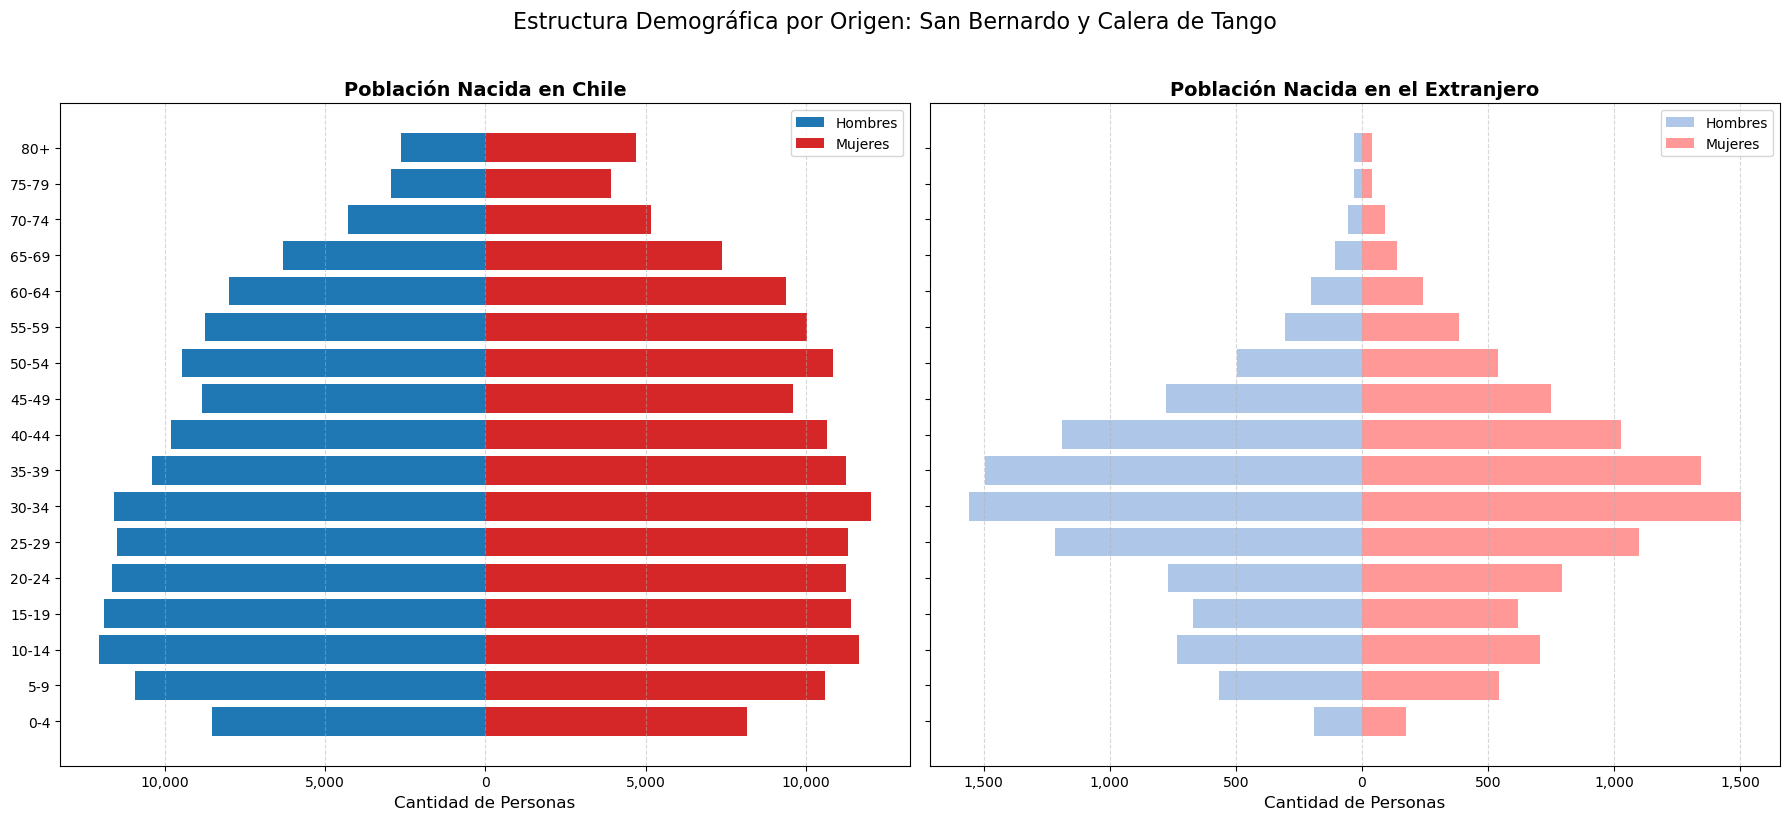

In [25]:
# Acá utilizamos el código que nos dió el profe en la isntrucciones de la tarea
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df["age_group"] = pd.cut(df["edad"], bins=bins, labels=labels, right=False)

# Decodificamos las variables para que el gráfico sea legible
# Asumiendo estándares del Censo (1 Hombre/2 Mujer, 1 Chile/2 Extranjero)
df["sexo_str"] = df["sexo"].map({1: "Hombre", 2: "Mujer"})
df["origen"] = df["p25_lug_nacimiento_rec"].map({1: "Nacido en Chile", 2: "Nacido en el Extranjero"})

# Ahora agrupamos por grupo de edad, sexo y origen, contando personas
grouped = df.groupby(['age_group', 'sexo_str', 'origen'], observed=False).size().reset_index(name='count')

# En esta parte aplicamos una función auxiliar para extraer conteos ordenados por edad para una combinación específica, la cual nos recomendó la IA
def get_counts(dataframe, origen, sexo):
    # Filtramos por origen y sexo
    data_subset = dataframe[(dataframe['origen'] == origen) & (dataframe['sexo_str'] == sexo)]
    # Ahora la IA nos recomendó que usaramos reindex para asegurar que todos los grupos de edad estén presentes y en orden
    return data_subset.set_index('age_group')['count'].reindex(labels).fillna(0).values

# Extraemos los arreglos numéricos para cada gráfico
hombres_cl = get_counts(grouped, "Nacido en Chile", "Hombre")
mujeres_cl = get_counts(grouped, "Nacido en Chile", "Mujer")
hombres_ext = get_counts(grouped, "Nacido en el Extranjero", "Hombre")
mujeres_ext = get_counts(grouped, "Nacido en el Extranjero", "Mujer")

# Posiciones en el eje Y
y_pos = np.arange(len(labels))

# Procedemos a crear 2 gráficos para que se pueda hacer una buena distinción
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Grafico 1: Chilenos
# Usamos colores azules/rojos oscuros para Chile
axes[0].barh(y_pos, -hombres_cl, color='#1f77b4', label='Hombres') 
axes[0].barh(y_pos, mujeres_cl, color='#d62728', label='Mujeres')  
axes[0].set_title('Población Nacida en Chile', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de Personas', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].legend()

# Configuraciones del eje Y  
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(labels)

# Formatear el eje X para que no muestre números negativos
ticks = axes[0].get_xticks()
axes[0].set_xticklabels([f"{abs(int(tick)):,}" for tick in ticks])

# Gráfico 2: Extranjeros
# Usamos colores más claros/pasteles para diferenciar
axes[1].barh(y_pos, -hombres_ext, color='#aec7e8', label='Hombres')
axes[1].barh(y_pos, mujeres_ext, color='#ff9896', label='Mujeres')
axes[1].set_title('Población Nacida en el Extranjero', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad de Personas', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
axes[1].legend()

# Formatear el eje X del segundo gráfico
ticks = axes[1].get_xticks()
axes[1].set_xticklabels([f"{abs(int(tick)):,}" for tick in ticks])

# Título principal de la figura
plt.suptitle('Estructura Demográfica por Origen: San Bernardo y Calera de Tango', fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

Podemos visualizar que el gráficos de las personas nacidas en Chile contienen hasta 10 veces más población que la extranjera. Se visualiza que la población va creciendo hasta el rango de loa 10-14 años donde luego de eso se va a la baja levemente hasta llegar a los 80+. Nada llama más la atención.

Sin embargo, la cosa se pone interesante en la de extranjero. Acá se visualiza que la distribución de los datos aparenta una de tipo Normal, donde la mayor cantidad se ve representada en el rango de 30-34 y 35-40. Esto no es de mucha sorpresa, ya que esa es la edad de las personas que migran de sus paises en busqueda de una mejor vida. Ahora, analizando que el rango de los niños y adolecente de vs la de los adultos mayores gana la primera, esto se podría explicar porque los adultos vienen con sus hijos a nuestro país y que son las pocas familias que viene con sus abuelos. 

### Parte 1.2

In [27]:
# Partimos esta parte agrupando por comuna y contamos cuántas personas caen en cada rango de edad
pop_0_14 = df[df['edad'] <= 14].groupby('comuna').size()
pop_15_64 = df[(df['edad'] >= 15) & (df['edad'] <= 64)].groupby('comuna').size()
pop_65_plus = df[df['edad'] >= 65].groupby('comuna').size()

# Consolidamos todo en un nuevo DataFrame
dependencia_df = pd.DataFrame({
    'Población 0-14': pop_0_14,
    'Población 15-64': pop_15_64,
    'Población 65+': pop_65_plus
})

# Aplicamos la fórmula: (0-14 + 65+) / 15-64 (la cuales la que nos da el profe)
dependencia_df['Índice de Dependencia'] = (dependencia_df['Población 0-14'] + dependencia_df['Población 65+']) / dependencia_df['Población 15-64']

# Mapeamos los códigos numéricos a los nombres de tus comunas
mapa_comunas = {13401: 'San Bernardo', 13403: 'Calera de Tango'}
dependencia_df.index = dependencia_df.index.map(mapa_comunas)
dependencia_df.index.name = 'Comuna'

# Redondeamos el índice a 2 decimales para que se vea mejor
dependencia_df['Índice de Dependencia'] = dependencia_df['Índice de Dependencia'].round(2)

# Reiniciamos el índice para que "Comuna" sea una columna normal y la tabla se imprima linda
tabla_final = dependencia_df.reset_index()

# Mostramos la tabla
display(tabla_final) # display() hace que la tabla se vea con formato HTML bonito en Colab/Jupyter

,Comuna,Población 0-14,Población 15-64,Población 65+,Índice de Dependencia
0,San Bernardo,60805,210882,34684,0.45
1,Calera de Tango,4593,17463,3435,0.46


Como grupo nosotros esperabamos un índice aproximadamente entre el 30% y el 50%. Al observar la tabla notamos que nuestra hipótesis es la correcta y nos llama la atención particularmente que por más que San Bernardo tenga mucha más población que Calera de Tango, sigue la misma proporción de dependencía. 

### Parte 1.3

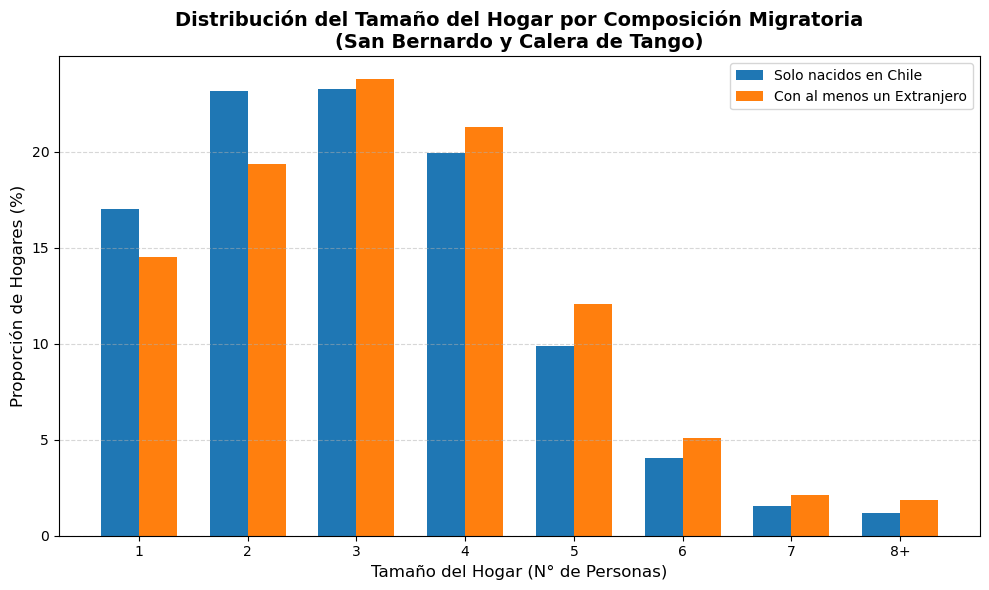

In [29]:
# Partimos esta parte agrupando por vivienda y hogar para obtener estadísticas por cada familia/hogar
hogares_stats = df.groupby(['id_vivienda', 'id_hogar']).agg(
    # Contamos cuántas personas hay en el hogar
    tamano_hogar=('id_persona', 'count'),
    # Revisamos si hay AL MENOS UNA persona nacida en el extranjero (código 2)
    tiene_extranjero=('p25_lug_nacimiento_rec', lambda x: (x == 2).any())
).reset_index()

# Categorizamos los hogares
hogares_stats['tipo_hogar'] = hogares_stats['tiene_extranjero'].map(
    {False: 'Hogares sin inmigrantes', True: 'Hogares con inmigrantes'}
)

# Topeamos el tamaño del hogar a 8 (todos los de 8 o más quedan como 8)
hogares_stats['tamano_top8'] = hogares_stats['tamano_hogar'].apply(lambda x: x if x < 8 else 8)

# Creamos etiquetas de texto para el eje X
size_labels = {1:'1', 2:'2', 3:'3', 4:'4', 5:'5', 6:'6', 7:'7', 8:'8+'}
hogares_stats['tamano_str'] = hogares_stats['tamano_top8'].map(size_labels)

# Contamos cuántos hogares hay de cada tamaño por tipo
distribucion = hogares_stats.groupby(['tipo_hogar', 'tamano_str', 'tamano_top8']).size().reset_index(name='conteo')

# Calculamos el total de hogares por tipo para sacar el %
totales_por_tipo = distribucion.groupby('tipo_hogar')['conteo'].transform('sum')
distribucion['proporcion'] = (distribucion['conteo'] / totales_por_tipo) * 100

# Ordenamos por tamaño para que el gráfico salga en orden numérico
distribucion = distribucion.sort_values(['tipo_hogar', 'tamano_top8'])

#Ahora nos vamos con toda la parte de gráficar 
# Separamos los datos para las dos barras
sin_inm = distribucion[distribucion['tipo_hogar'] == 'Hogares sin inmigrantes']
con_inm = distribucion[distribucion['tipo_hogar'] == 'Hogares con inmigrantes']

# Configuraciones del gráfico de barras agrupadas
x = np.arange(8)  # Posiciones en el eje X (0 al 7)
width = 0.35      # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujamos las barras (desplazando un poco a la izquierda y derecha para que no se superpongan)
ax.bar(x - width/2, sin_inm['proporcion'], width, label='Solo nacidos en Chile', color='#1f77b4')
ax.bar(x + width/2, con_inm['proporcion'], width, label='Con al menos un Extranjero', color='#ff7f0e')

# Formato del gráfico
ax.set_ylabel('Proporción de Hogares (%)', fontsize=12)
ax.set_xlabel('Tamaño del Hogar (N° de Personas)', fontsize=12)
ax.set_title('Distribución del Tamaño del Hogar por Composición Migratoria\n(San Bernardo y Calera de Tango)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([size_labels[i] for i in range(1, 9)])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

A simple vista se ve que entre 1 y 2 integrantes gana las personas nacidad en Chile. Pero de 3 en adelante, se visualiza todo lo contrario, que si la familia contiene al menos 1 persona extranjera, ellos son los que les gana en tema de porcentaje a los que solo están conformadas de Chilenos. Esto puede deber a varios factores como económicos, familiares, etc.

### Parte 1.4

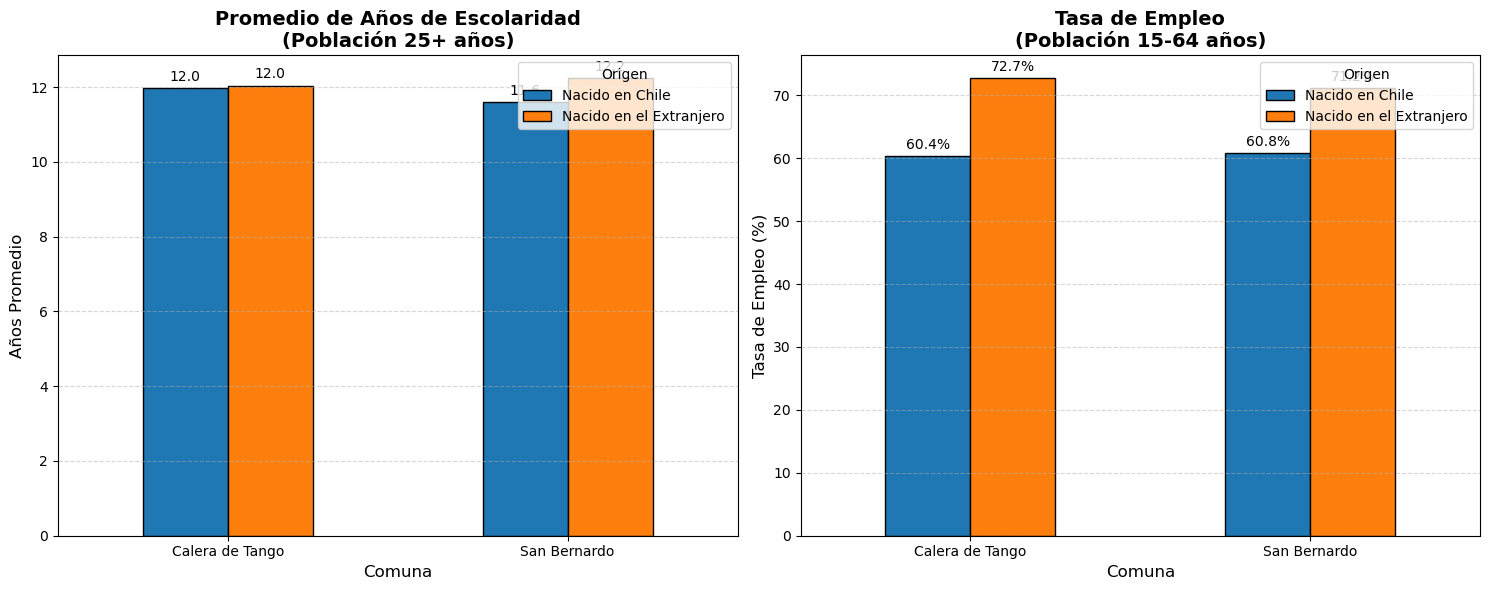

In [31]:
mapa_comunas = {13401: 'San Bernardo', 13403: 'Calera de Tango'}
df['nombre_comuna'] = df['comuna'].map(mapa_comunas)

# Aseguramos que la columna origen exista
if 'origen' not in df.columns:
    df['origen'] = df['p25_lug_nacimiento_rec'].map({1: 'Nacido en Chile', 2: 'Nacido en el Extranjero'})

#Ahora vamos a calcular el promedio de la escolaridad
# Filtramos: edad >= 25, sin -99 en escolaridad, y que tengan origen válido
df_educ = df[(df['edad'] >= 25) & (df['escolaridad'] != -99) & (df['origen'].notna())]

# Calculamos el promedio
educ_stats = df_educ.groupby(['nombre_comuna', 'origen'])['escolaridad'].mean().unstack()

#Ahora calculamos la tasa de empleo
# Filtramos: edad entre 15 y 64, sin -99 en situación laboral, y origen válido
df_emp = df[(df['edad'] >= 15) & (df['edad'] <= 64) & (df['sit_fuerza_trabajo'] != -99) & (df['origen'].notna())].copy()

# Calculamos la proporción de ocupados (código 1) y multiplicamos por 100
df_emp['empleado'] = (df_emp['sit_fuerza_trabajo'] == 1)
emp_stats = df_emp.groupby(['nombre_comuna', 'origen'])['empleado'].mean().unstack() * 100

#Finalmente procederemos a crear el gráfico 1 y 2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
color_cl = '#1f77b4'
color_ext = '#ff7f0e'

# Gráfico 1: Escolaridad
educ_stats.plot(kind='bar', ax=axes[0], color=[color_cl, color_ext], edgecolor='black')
axes[0].set_title('Promedio de Años de Escolaridad\n(Población 25+ años)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Años Promedio', fontsize=12)
axes[0].set_xlabel('Comuna', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Origen')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Etiquetas sobre barras
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', label_type='edge', padding=3)

# Gráfico 2: Empleo
emp_stats.plot(kind='bar', ax=axes[1], color=[color_cl, color_ext], edgecolor='black')
axes[1].set_title('Tasa de Empleo\n(Población 15-64 años)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tasa de Empleo (%)', fontsize=12)
axes[1].set_xlabel('Comuna', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Origen')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Etiquetas sobre barras
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

Para el gráfico de la izquierda, se logra visualizar una leve diferencía a favor de los nacidos fuera de Chile en San Bernardo. En Calera de Tango sopresivamente se ve igual.

Si nos vamos al gráfico de la derecha la cosa se pone más interesante, ya que en ambas comunas, los nacidos en el extranjero poseen una mayor tasa de empleabilidad vs los nacidos en Chile. Esto se puede deber a que los extranjeros por su condición a veces de ilegales, aceptan trabajos que los chilenos pedirian más ingresos por menos. Tambien si es que uno se va al principal motivo de por qué dichas personas deciden migrar a Chile (la cual es por mayor ingresos con los trabajos), calza bastante

## Parte 2
### Parte 2.1

--- Tabla: Porcentaje de Nacidos en el Extranjero ---


origen,nombre_comuna,Porcentaje_Extranjeros (%)
0,Calera de Tango,3.55
1,San Bernardo,6.42


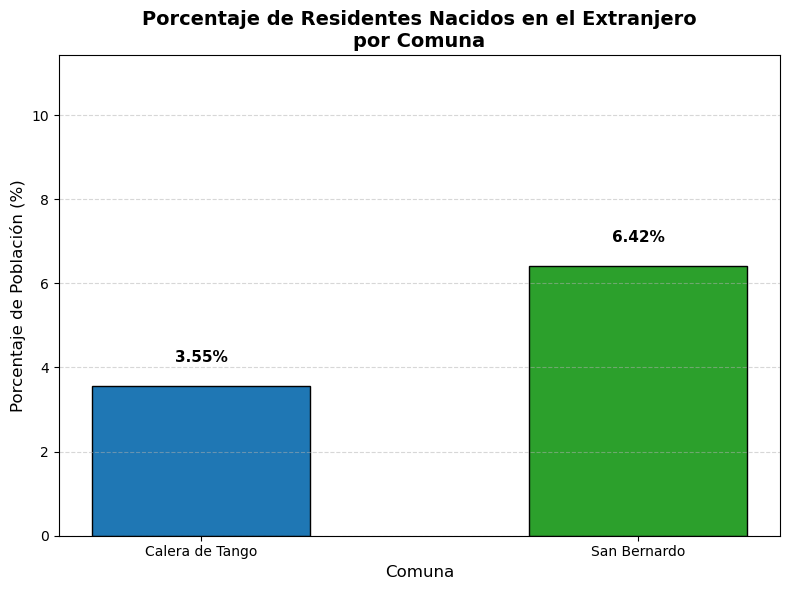

In [33]:
#Partimos caculando los porcentajes
# Agrupamos por comuna y origen, y contamos cuántas personas hay en cada cruce
origen_stats = df.groupby(['nombre_comuna', 'origen']).size().unstack(fill_value=0)

# Calculamos el total de población por comuna
origen_stats['Total_Poblacion'] = origen_stats.sum(axis=1)

# Calculamos el porcentaje de nacidos en el extranjero
origen_stats['Porcentaje_Extranjeros (%)'] = (origen_stats['Nacido en el Extranjero'] / origen_stats['Total_Poblacion']) * 100

#Ahora creamos la tabla y el gráfico de barras que se solicita
# Seleccionamos solo la columna del porcentaje y redondeamos a 2 decimales
tabla_extranjeros = origen_stats[['Porcentaje_Extranjeros (%)']].round(2).reset_index()

print("--- Tabla: Porcentaje de Nacidos en el Extranjero ---")
display(tabla_extranjeros)

fig, ax = plt.subplots(figsize=(8, 6))

# Dibujamos las barras (usamos colores distintos para cada comuna para que se vea mejor)
colores = ['#1f77b4', '#2ca02c']
bars = ax.bar(tabla_extranjeros['nombre_comuna'], tabla_extranjeros['Porcentaje_Extranjeros (%)'], 
              color=colores, edgecolor='black', width=0.5)

# Formato del gráfico
ax.set_title('Porcentaje de Residentes Nacidos en el Extranjero\npor Comuna', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje de Población (%)', fontsize=12)
ax.set_xlabel('Comuna', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Damos un poco de espacio extra en el eje Y para que los números no se corten
ax.set_ylim(0, tabla_extranjeros['Porcentaje_Extranjeros (%)'].max() + 5)

# Añadir el valor exacto sobre cada barra
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Acá no hay mucho que interpretar más que quisimos hacer una pequeña búsqueda de cual era el promedio de % de extranjeros en todas las comúnas de Chile y nos arrojó que era aproximadamente de un 9%, por lo que estás comunas se encuentran por de bajo de ese promedio. 

### Parte 2.2

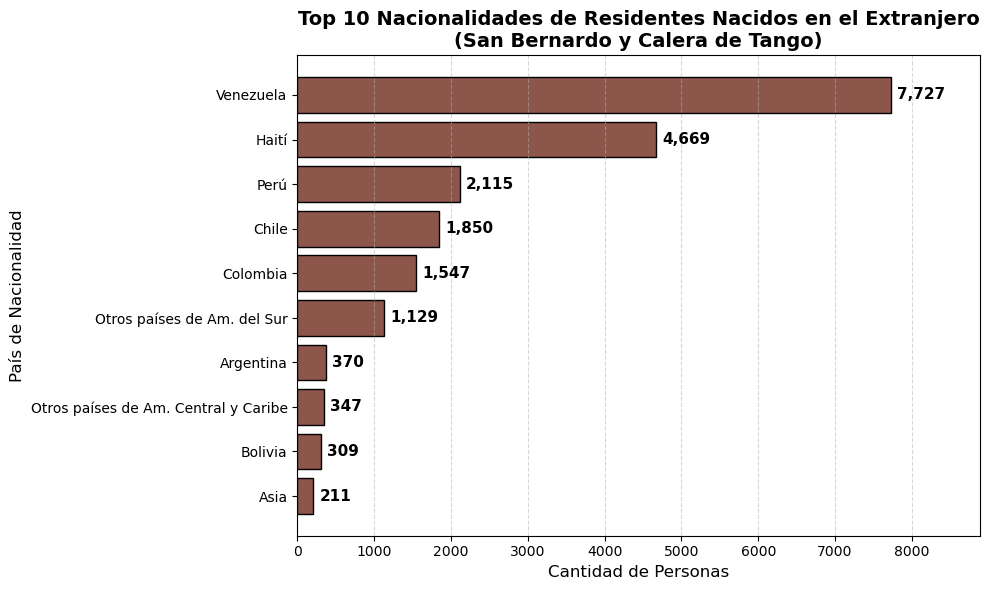

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

#Acá filtramos los extranejors
df_ext = df[df['p25_lug_nacimiento_rec'] == 2].copy()

#Esto son los códigos que expresan de que nacionalidad son los extranjeros que habitan en las comúnas que hemos trabajado
mapeo_paises = {
    862: 'Venezuela',
    604: 'Perú',
    170: 'Colombia',
    332: 'Haití',
    68:  'Bolivia',
    32:  'Argentina',
    218: 'Ecuador',
    214: 'Rep. Dominicana',
    76:  'Brasil',
    192: 'Cuba',
    724: 'España',
    840: 'Estados Unidos',
    156: 'China',
    600: 'Paraguay',
    858: 'Uruguay',
    5: 'Otros países de Am. del Sur',
    13: 'Otros países de Am. Central y Caribe',
    142: 'Asia',
    152: 'Chile' # A veces chilenos nacidos en el exterior aparecen aquí
}

# Aplicamos el mapeo a la columna p27_nacionalidad_esp
df_ext['nacionalidad_str'] = df_ext['p27_nacionalidad_esp'].map(mapeo_paises)

# Si un número no estaba en nuestro diccionario, le ponemos "Código [Número]" 
# para que sepas que hay que buscarlo en el Excel
df_ext['nacionalidad_str'] = df_ext['nacionalidad_str'].fillna(
    "Código " + df_ext['p27_nacionalidad_esp'].astype(str)
)

#Acá buscamos el top 10
# Contamos cuántos hay de cada nacionalidad, sacamos los 10 primeros
top_10 = df_ext['nacionalidad_str'].value_counts().head(10)

# Invertimos el orden (para que en el gráfico horizontal el #1 quede arriba del todo)
top_10 = top_10.sort_values(ascending=True)

#acá empezamos a gráficar 
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras horizontales (barh)
bars = ax.barh(top_10.index, top_10.values, color='#8c564b', edgecolor='black')

ax.set_title('Top 10 Nacionalidades de Residentes Nacidos en el Extranjero\n(San Bernardo y Calera de Tango)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Personas', fontsize=12)
ax.set_ylabel('País de Nacionalidad', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Poner los numeritos de conteo al final de cada barra para que se lea fácil
for bar in bars:
    ax.text(bar.get_width() + (top_10.max() * 0.01), 
            bar.get_y() + bar.get_height()/2,        
            f'{int(bar.get_width()):,}',             
            va='center', fontweight='bold', fontsize=11)

# Extender un poco el límite X para que el número de la barra más larga no se corte
ax.set_xlim(0, top_10.max() * 1.15)

plt.tight_layout()
plt.show()

Acá no es sorpersa para nadie que el top 3 sean los mismos paises que encabezan con la mayor cantidad de inmigrantes en nuestro país. Lo que si se puede llegar a destacar es que en este caso, Venezuela casi duplica en personas a Haití.

### Parte 2.4

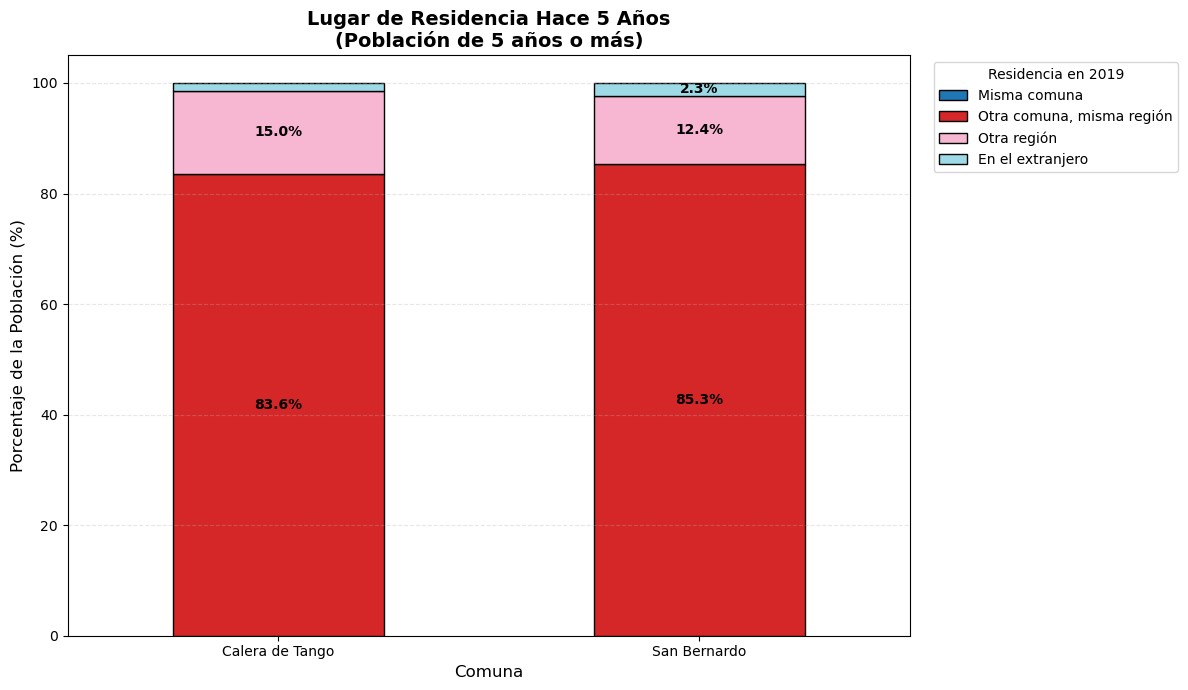

In [44]:
#Patimos filtrando los datos con la edad mayor o igual a 5 años
df_5 = df[df['edad'] >= 5].copy()

# Este diccionario cubre todas las posibilidades (número, texto, decimal)
#Esto lo ocupo porque la IA me lo recomendó 
mapeo_resid = {
    1: 'Misma comuna', 1.0: 'Misma comuna', '1': 'Misma comuna', '1.0': 'Misma comuna',
    2: 'Otra comuna, misma región', 2.0: 'Otra comuna, misma región', '2': 'Otra comuna, misma región', '2.0': 'Otra comuna, misma región',
    3: 'Otra región', 3.0: 'Otra región', '3': 'Otra región', '3.0': 'Otra región',
    4: 'En el extranjero', 4.0: 'En el extranjero', '4': 'En el extranjero', '4.0': 'En el extranjero'
}

# Aplicamos el mapeo directamente sobre la columna original
df_5['resid_5_str'] = df_5['p24_lug_resid5'].map(mapeo_resid)

# Filtramos solo los que logramos mapear (eliminamos -99 o valores raros)
df_final = df_5[df_5['resid_5_str'].notna()].copy()

#Acá calculamos el porcentaje
res_stats = df_final.groupby(['nombre_comuna', 'resid_5_str']).size().unstack(fill_value=0)

# DEFINIMOS EL ORDEN QUE QUEREMOS
orden_columnas = ['Misma comuna', 'Otra comuna, misma región', 'Otra región', 'En el extranjero']

# USAMOS REINDEX: Si falta una categoría, crea la columna con ceros en vez de dar error
res_pct = res_stats.reindex(columns=orden_columnas, fill_value=0)

# Convertimos a porcentajes por fila
res_pct = res_pct.div(res_pct.sum(axis=1), axis=0) * 100

#ahora procedemos a fráficar
fig, ax = plt.subplots(figsize=(12, 7))

# Graficamos
res_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='black')

ax.set_title('Lugar de Residencia Hace 5 Años\n(Población de 5 años o más)', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje de la Población (%)', fontsize=12)
ax.set_xlabel('Comuna', fontsize=12)
ax.legend(title='Residencia en 2019', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Añadir etiquetas solo si el porcentaje es mayor a 2%
for c in ax.containers:
    labels = [f'{w:.1f}%' if w > 2 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Al analizar dónde vivían los residentes hace cinco años, lo que más salta a la vista es el increíble dinamismo migratorio interno de ambas comunas. San Bernardo y Calera de Tango funcionan como verdaderos imanes dentro de la Región Metropolitana: más del 83% de sus habitantes actuales vivía en otra comuna de la misma región en 2019.

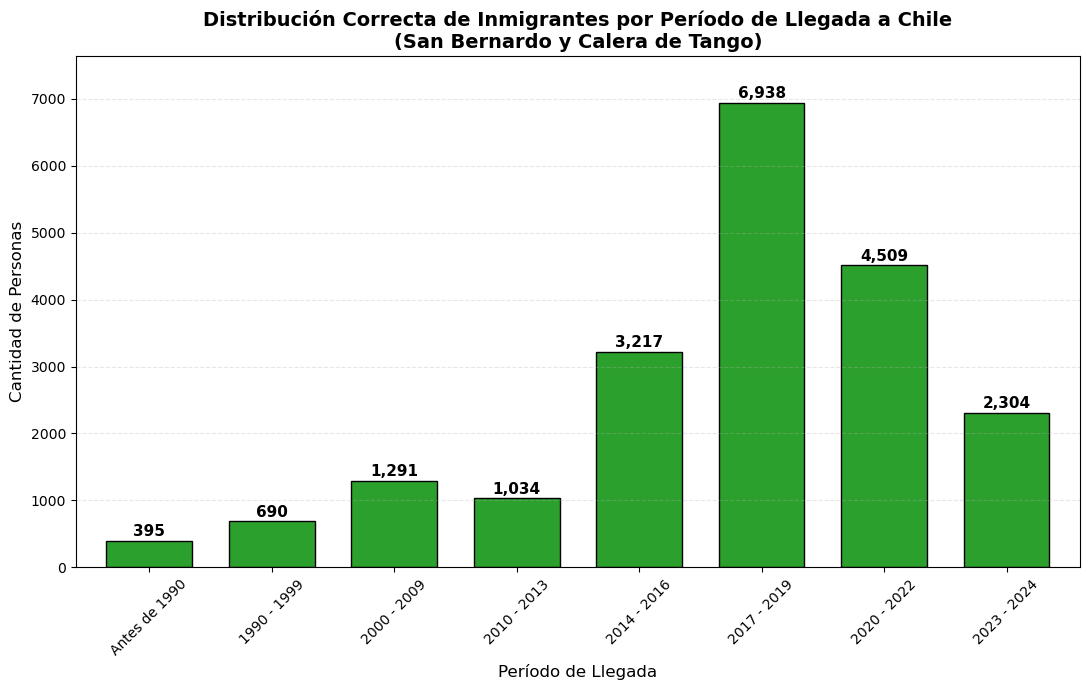

In [48]:
#Acá filtramos solo por extranjero
# Nos aseguramos de tener la columna origen para filtrar
if 'p25_lug_nacimiento_rec' not in df.columns:
    df['origen_code'] = df['p25_lug_nacimiento_rec'].fillna(-99)
else:
    df['origen_code'] = df['p25_lug_nacimiento_rec']

# Filtramos: Solo nacidos en el extranjero (código 2) y excluimos faltantes (-99)
df_ext_val = df[(df['origen_code'] == 2) & (df['p26_llegada_periodo'] != -99)].copy()

#Acá nos vasamos en los datos del excel
# Agregamos las versiones numéricas, decimales y de texto para evitar errores
mapeo_periodos_final = {
    1: '2023 - 2024', 1.0: '2023 - 2024', '1': '2023 - 2024', '1.0': '2023 - 2024',
    2: '2020 - 2022', 2.0: '2020 - 2022', '2': '2020 - 2022', '2.0': '2020 - 2022',
    3: '2017 - 2019', 3.0: '2017 - 2019', '3': '2017 - 2019', '3.0': '2017 - 2019',
    4: '2014 - 2016', 4.0: '2014 - 2016', '4': '2014 - 2016', '4.0': '2014 - 2016',
    5: '2010 - 2013', 5.0: '2010 - 2013', '5': '2010 - 2013', '5.0': '2010 - 2013',
    6: '2000 - 2009', 6.0: '2000 - 2009', '6': '2000 - 2009', '6.0': '2000 - 2009',
    7: '1990 - 1999', 7.0: '1990 - 1999', '7': '1990 - 1999', '7.0': '1990 - 1999',
    8: 'Antes de 1990', 8.0: 'Antes de 1990', '8': 'Antes de 1990', '8.0': 'Antes de 1990'
}

# Aplicamos el mapeo directamente sobre la columna original
df_ext_val['periodo_llegada'] = df_ext_val['p26_llegada_periodo'].map(mapeo_periodos_final)

# Filtramos solo los que logramos mapear (por si acaso)
df_llegada_clean = df_ext_val[df_ext_val['periodo_llegada'].notna()].copy()

#Calculo de la distribución
# Contamos cuántas personas llegaron en cada periodo
dist_llegada = df_llegada_clean['periodo_llegada'].value_counts()

# ORDENAMOS CRONOLÓGICAMENTE (de más antiguo a más reciente)
orden_cronologico = [
    'Antes de 1990', '1990 - 1999', '2000 - 2009', 
    '2010 - 2013', '2014 - 2016', '2017 - 2019', 
    '2020 - 2022', '2023 - 2024'
]

# Usamos reindex para ordenar y llenar con 0 si algún periodo no tiene datos
dist_llegada = dist_llegada.reindex(orden_cronologico, fill_value=0)

#Ahora vamos con toda la parte de graficar 
plt.figure(figsize=(11, 7))
bars = dist_llegada.plot(kind='bar', color='#2ca02c', edgecolor='black', width=0.7)

plt.title('Distribución Correcta de Inmigrantes por Período de Llegada a Chile\n(San Bernardo y Calera de Tango)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.xlabel('Período de Llegada', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Añadir etiquetas de conteo exacto sobre las barras
for i, v in enumerate(dist_llegada):
    if v > 0:
        plt.text(i, v + (dist_llegada.max() * 0.01), f'{int(v):,}', 
                 ha='center', fontweight='bold', fontsize=11)

# Ajuste fino del límite Y para que no se corten los números
plt.ylim(0, dist_llegada.max() * 1.1)

plt.tight_layout()
plt.show()

Calza perfectamente con el contexto político, donde cercano del 2020 fue donde existió el peak de inmigrante sobre todo de nacionalidad Venezolana por las dificultades económicas que afronta su país.

## Parte 3
### Parte 3.1

Shapefile cargado exitosamente.


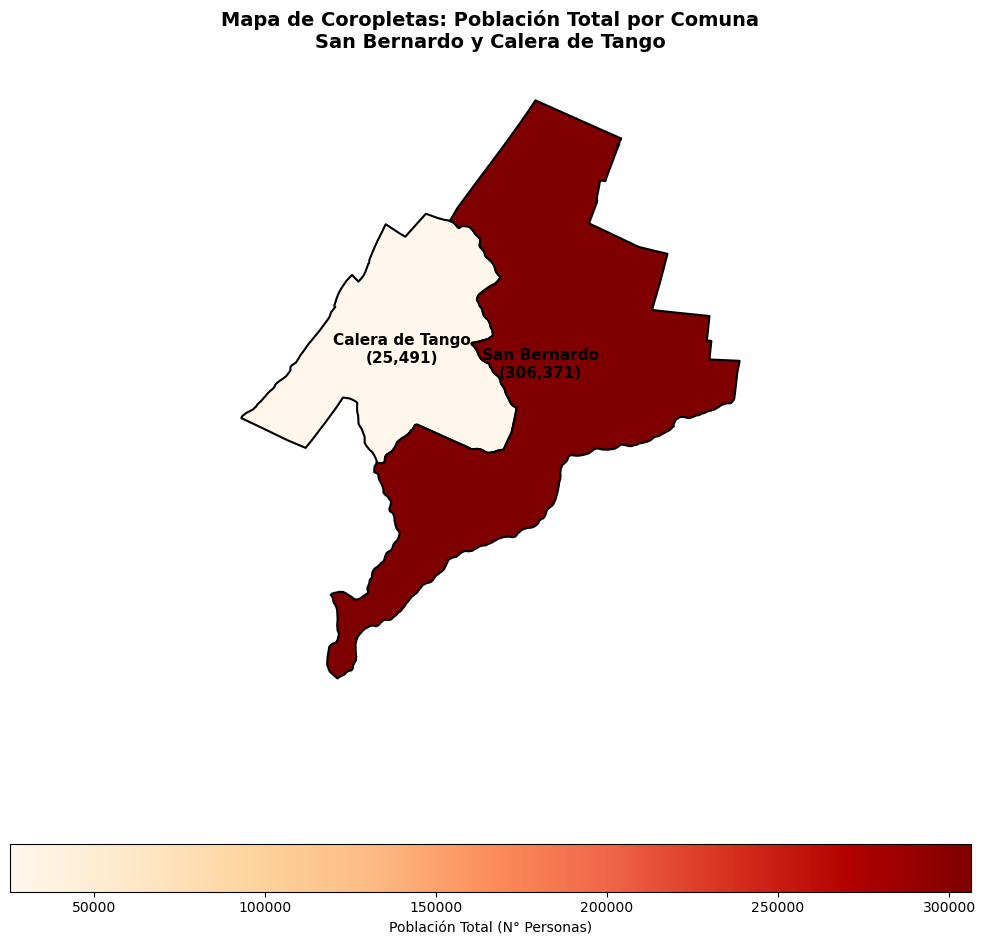

In [52]:
comuna_pop = df.groupby('comuna').size().reset_index(name='poblacion_total')

# Mapeo de nombres (para leyendas y etiquetas)
mapa_comunas = {13401: 'San Bernardo', 13403: 'Calera de Tango'}
comuna_pop['nombre_comuna'] = comuna_pop['comuna'].map(mapa_comunas)

#Cargar la ruta
shp_path = "C:/Users/Mateo/Downloads/comunas.shp"

try:
    comunas_gdf = gpd.read_file(shp_path)
    print("Shapefile cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo en '{shp_path}'.")
    print("Por favor, asegúrate de haber subido la carpeta 'materials' a tu entorno de trabajo.")
    # Detenemos la ejecución si no hay shapefile
    raise

#Ahora lo unimos con el merge
nombre_columna_shp = 'cod_comuna' # AJUSTA ESTO SI TU SHAPEFILE ES DISTINTO

# Convertimos la columna del Shapefile a entero por seguridad
try:
    comunas_gdf[nombre_columna_shp] = comunas_gdf[nombre_columna_shp].astype(int)
except (ValueError, TypeError):
    print(f"Warning: No se pudo convertir '{nombre_columna_shp}' a entero. El merge podría fallar.")

# Unimos (Merge) los datos de población al GeoDataFrame
merged_gdf = comunas_gdf.merge(comuna_pop, left_on=nombre_columna_shp, right_on='comuna', how='left')

#Filtrar por las comunas que necesito
assigned_codes = list(mapa_comunas.keys())
mis_comunas_gdf = merged_gdf[merged_gdf['comuna'].isin(assigned_codes)].copy()

# Eliminamos geometrías vacías por si acaso
mis_comunas_gdf = mis_comunas_gdf[~mis_comunas_gdf.geometry.is_empty]

#Ahora empezamos el proceso para graficar 
if not mis_comunas_gdf.empty:
    fig, ax = plt.subplots(figsize=(10, 10))

    # Graficamos las coropletas
    mis_comunas_gdf.plot(column='poblacion_total', # Columna que define el color
                         cmap='OrRd',              # Mapa de colores (Naranja-Rojo)
                         legend=True,              # Mostrar barra de color
                         legend_kwds={'label': "Población Total (N° Personas)", 'orientation': "horizontal"},
                         ax=ax,
                         edgecolor='black',        # Bordes de comunas
                         linewidth=1.5)

    # --- Añadir etiquetas de texto (Nombre y Población) ---
    for x, y, label, pop in zip(mis_comunas_gdf.geometry.centroid.x, 
                               mis_comunas_gdf.geometry.centroid.y, 
                               mis_comunas_gdf['nombre_comuna'],
                               mis_comunas_gdf['poblacion_total']):
        ax.text(x, y, f"{label}\n({int(pop):,})", fontsize=11, fontweight='bold', ha='center', va='center', color='black')

    # Ajustes finales
    ax.set_title('Mapa de Coropletas: Población Total por Comuna\nSan Bernardo y Calera de Tango', fontsize=14, fontweight='bold')
    ax.axis('off') # Quitar ejes cartesianos para vista limpia

    plt.tight_layout()
    plt.show()
else:
    print("ERROR: No se encontraron tus comunas en el shapefile después de la unión.")

Viendo que San Bernado casi el doble de tamaño que Calera de tango, calza bastante la cantidad de personas que habitan dicha comuna y todos los resultados anteriores tambien concuerdan 

Shapefile cargado exitosamente.


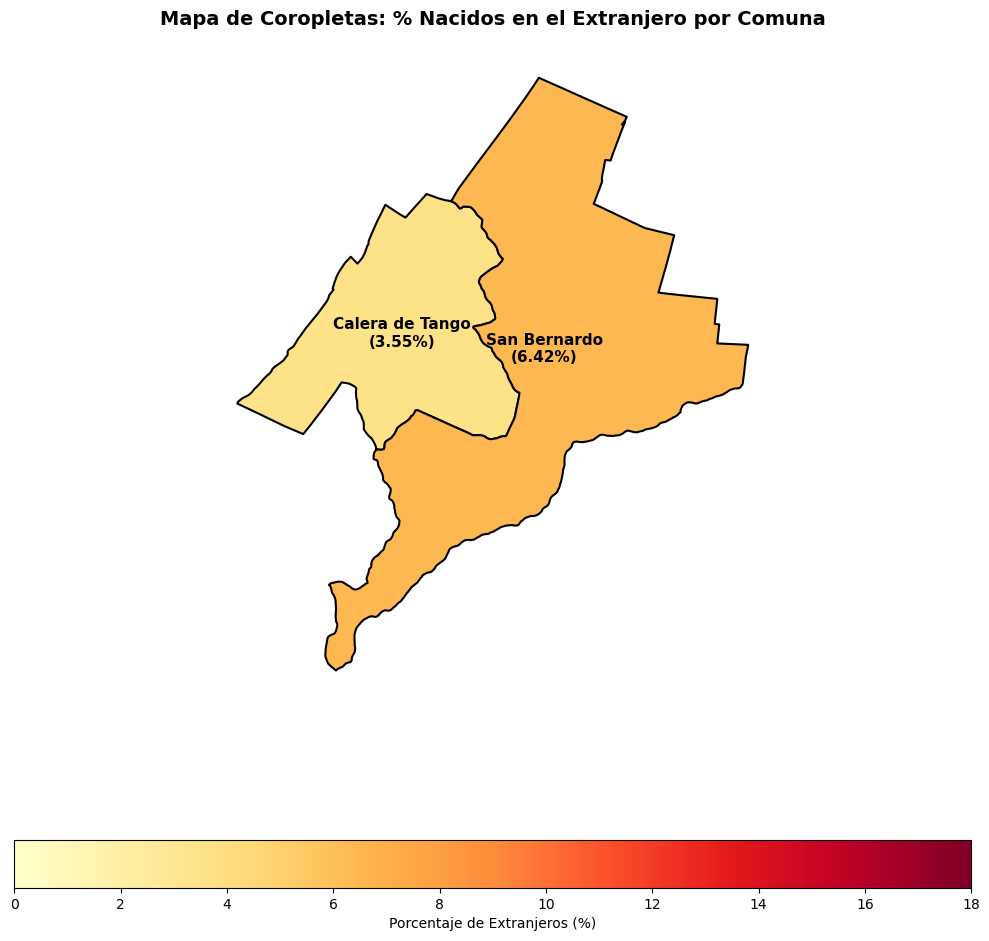

In [56]:
# Agrupamos por comuna y origen para calcular el %
stats_ext = df.groupby(['comuna', 'origen']).size().unstack(fill_value=0)
stats_ext['Total'] = stats_ext.sum(axis=1)

# Calculamos el % de extranjeros (Nacido en el Extranjero / Total) * 100
stats_ext['pct_extranjeros'] = (stats_ext['Nacido en el Extranjero'] / stats_ext['Total']) * 100
stats_ext = stats_ext[['pct_extranjeros']].reset_index()

# Mapeo de nombres para las etiquetas
mapa_comunas = {13401: 'San Bernardo', 13403: 'Calera de Tango'}
stats_ext['nombre_comuna'] = stats_ext['comuna'].map(mapa_comunas)

#cargamos la ruta
shp_path = "C:/Users/Mateo/Downloads/comunas.shp"

try:
    comunas_gdf = gpd.read_file(shp_path)
    print("Shapefile cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo en '{shp_path}'.")
    raise

#Volvemos a unir 
nombre_columna_shp = 'cod_comuna'

comunas_gdf[nombre_columna_shp] = comunas_gdf[nombre_columna_shp].astype(int)
merged_gdf_pct = comunas_gdf.merge(stats_ext, left_on=nombre_columna_shp, right_on='comuna', how='left')

# Filtrar por tus comunas
assigned_codes = list(mapa_comunas.keys())
mis_comunas_pct = merged_gdf_pct[merged_gdf_pct['comuna'].isin(assigned_codes)].copy()
mis_comunas_pct = mis_comunas_pct[~mis_comunas_pct.geometry.is_empty]

#Ahora empezamos el proceso de gráficar 
if not mis_comunas_pct.empty:
    fig, ax = plt.subplots(figsize=(10, 10))

    # CLAVE: vmin=0 y vmax=12 fijan la escala de la leyenda
    mis_comunas_pct.plot(column='pct_extranjeros', 
                         cmap='YlOrRd', 
                         vmin=0,      # El color más claro será 0%
                         vmax=18,     # El color más oscuro será 12%
                         legend=True, 
                         legend_kwds={'label': "Porcentaje de Extranjeros (%)", 'orientation': "horizontal"},
                         ax=ax,
                         edgecolor='black', 
                         linewidth=1.5)

    # Etiquetas
    for x, y, label, pct in zip(mis_comunas_pct.geometry.centroid.x, 
                               mis_comunas_pct.geometry.centroid.y, 
                               mis_comunas_pct['nombre_comuna'],
                               mis_comunas_pct['pct_extranjeros']):
        ax.text(x, y, f"{label}\n({pct:.2f}%)", fontsize=11, fontweight='bold', ha='center', va='center', color='black')

    ax.set_title('Mapa de Coropletas: % Nacidos en el Extranjero por Comuna', 
                 fontsize=14, fontweight='bold')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

Acá para dejarlo a corde con lo que mencioné anteriormente, puse el 9% como el promedio de las comunas de Chile, entonces se logra evidenciar la poca cantidiad de extranjeros en las comunas que nos tocó 

## Parte 4

In [59]:
import pandas as pd
import numpy as np
import os

# --- CONFIGURACIÓN CON TUS COLUMNAS REALES ---
VAR_ESCOLARIDAD = 'escolaridad'
VAR_EMPLEO = 'sit_fuerza_trabajo'

def build_summary(group):
    # 1. Identificadores básicos
    cod = group['comuna'].iloc[0]
    nom = group['nombre_comuna'].iloc[0]
    
    # 2. Poblaciones (1 = Chile, 2 = Extranjero según p25_lug_nacimiento_rec)
    chilean_mask = group['p25_lug_nacimiento_rec'] == 1
    foreign_mask = group['p25_lug_nacimiento_rec'] == 2
    
    pop_total = len(group)
    pop_chilean = chilean_mask.sum()
    pop_foreign = foreign_mask.sum()
    pct_foreign = (pop_foreign / pop_total) * 100 if pop_total > 0 else 0
    
    # 3. Edad Mediana (excluyendo -99)
    valid_age = group[group['edad'] != -99]
    med_age_chilean = valid_age[chilean_mask]['edad'].median()
    med_age_foreign = valid_age[foreign_mask]['edad'].median()
    
    # 4. Escolaridad Promedio (Solo 25+ años, excluyendo -99)
    esc_25 = group[(group['edad'] >= 25) & (group[VAR_ESCOLARIDAD] != -99)]
    mean_esc_chilean = esc_25[chilean_mask][VAR_ESCOLARIDAD].mean()
    mean_esc_foreign = esc_25[foreign_mask][VAR_ESCOLARIDAD].mean()
    
    # 5. Tasa de Empleo (15-64 años, excluyendo -99. 1 = Ocupado)
    emp_15_64 = group[(group['edad'] >= 15) & (group['edad'] <= 64) & (group[VAR_EMPLEO] != -99)]
    
    def calc_emp_rate(mask):
        total_fuerza = emp_15_64[mask].shape[0]
        ocupados = emp_15_64[mask & (group[VAR_EMPLEO] == 1)].shape[0]
        return (ocupados / total_fuerza * 100) if total_fuerza > 0 else 0
            
    emp_rate_chilean = calc_emp_rate(chilean_mask)
    emp_rate_foreign = calc_emp_rate(foreign_mask)

    # 6. Índice de Dependencia General
    fuerza = group[(group['edad'] >= 15) & (group['edad'] <= 64)].shape[0]
    dependientes = group[(group['edad'] < 15) | (group['edad'] > 64)].shape[0]
    dep_ratio = (dependientes / fuerza * 100) if fuerza > 0 else 0
    
    return pd.Series({
        'codigo_comuna': cod,
        'nombre_comuna': nom,
        'pop_total': pop_total,
        'pop_chilean': pop_chilean,
        'pop_foreign': pop_foreign,
        'pct_foreign': round(pct_foreign, 2),
        'median_age_chilean': med_age_chilean,
        'median_age_foreign': med_age_foreign,
        'mean_schooling_chilean': round(mean_esc_chilean, 2),
        'mean_schooling_foreign': round(mean_esc_foreign, 2),
        'emp_rate_chilean': round(emp_rate_chilean, 2),
        'emp_rate_foreign': round(emp_rate_foreign, 2),
        'dependency_ratio': round(dep_ratio, 2)
    })

# --- EJECUCIÓN FINAL ---

# 1. Agrupar y procesar
summary = df.groupby("comuna").apply(build_summary).reset_index(drop=True)

# 2. Mostrar tabla
print("--- Tarea 1: Tabla de Resumen Comunal Final ---")
display(summary)

# 3. Guardar archivo
if not os.path.exists('output'):
    os.makedirs('output')

summary.to_csv("output/tarea1_comuna_summary.csv", index=False)
print("\n¡Listo! El archivo maestro ha sido guardado en 'output/tarea1_comuna_summary.csv'")

C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\772581277.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mean_esc_chilean = esc_25[chilean_mask][VAR_ESCOLARIDAD].mean()
C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\772581277.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mean_esc_foreign = esc_25[foreign_mask][VAR_ESCOLARIDAD].mean()
C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\772581277.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total_fuerza = emp_15_64[mask].shape[0]
C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\772581277.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ocupados = emp_15_64[mask & (group[VAR_EMPLEO] == 1)].shape[0]
C:\Users\Mateo\AppData\Local\Temp\ipykernel_33868\772581277.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total_fuerza = emp_15_64[mask].shape[0]
C:\U

--- Tarea 1: Tabla de Resumen Comunal Final ---


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13401,San Bernardo,306371,284663,19544,6.38,34.0,33.0,11.60,12.24,60.81,71.16,45.28
1,13403,Calera de Tango,25491,24430,898,3.52,37.0,35.0,11.97,12.04,60.39,72.70,45.97



¡Listo! El archivo maestro ha sido guardado en 'output/tarea1_comuna_summary.csv'


La tabla resumen consolida las brechas y perfiles de ambas comunas. Mientras San Bernardo absorbe un volumen masivo de población, Calera de Tango mantiene un perfil más pequeño pero con indicadores de escolaridad levemente superiores. En ambas comunas destaca el aporte de la población extranjera a la fuerza laboral, con tasas de empleo que superan en más de 10 puntos porcentuales a la población local, y una estructura etaria más joven, lo que contribuye a dinamizar la demografía de la zona sur de la Región Metropolitana.